# Wstęp

Zadanie nr 13 wprowadza zagadnienie głębokich modeli uczenia ze wzmocnieniem (*Deep Reinforcement Learning*, **DRL**) - modeli, które uczone są przez interakcję z otoczeniem, obserwując konsekwencję działań oraz przyznawaną wartość nagrody.

## Cel ćwiczenia

Celem ćwiczenia jest zapoznanie z:
* koncepcją głębokiego uczenia ze wzmocnieniem,
* podstawowymi podejściami w głębokim uczeniu ze wzmocnieniem,
* przykładowymi środowiskami, wykorzystywanym w DRL,
* jedną z podstawowych metod DRL opartą na funkcji wartości.


# Głębokie uczenie ze wzmocnieniem

Podstawa reinforcement learning jest uczenie przez interakcje ̨: agent oddziałuje z otoczeniem i, obserwując konsekwencje jego działań, może uczyć się jak zmienić swoje zachowanie by zmaksymalizować wartość otrzymanej nagrody.

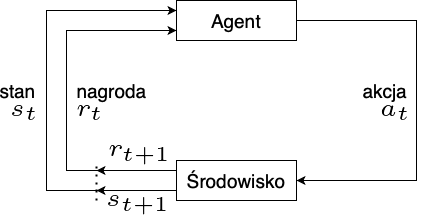

Zasada działania modelu uczenia ze wzmocnieniem jest następująca: autonomiczny agent, sterowany przez model, obserwuje **stan $s_t$ środowiska** w kroku czasowym $t$. Agent oddziałuje z otoczeniem podejmując **akcję $a_t$**, co powoduje przejście otoczenia i agenta do nowego stanu $s_{t+1}$. Przejście to odbywa się na podstawie **funkcji przejścia stanów $T(s_{t+1} | s_t, a_t)$** (równoważnej środowisku) - na podstawie aktualnego stanu i podjętej akcji. Zakładamy, że informacja o stanie jest wystarczająca dla agenta do podjęcia optymalnej akcji.

Sekwencja akcji wybierana jest na podstawie nagrody, przyznawanej przez otoczenie agentowi. Każde przejście środowiska do nowego stanu powoduje nagrodzenie agenta **nagrodą $r_t$**, tj. wartością skalarną, określającą "poprawność" podjętej decyzji. Celem uczenia modelu DRL jest wyuczenie **strategii**, maksymalizującej łączną uzyskiwaną wartość nagrody (*zwrot*).

Agent uczenia ze wzmocnieniem może składać się z następujących elementów (w zależności od stosowanego podejścia zawiera jeden lub więcej z nich):
* **strategia** (ang. *policy*), tj. funkcja zachowywania się agenta; może być deterministyczna $a = \pi(s)$ lub stochastyczna $\pi(a|s)=p(a_t=a | s_t=s)$;
* **funkcja wartości** (ang. *value function*), tj. funkcja służąca do predykcji przyszłej nagrody, używana do oceny stanów przy podejmowaniu akcji:
$$V_{\pi}(s)=\mathbb{E}\left[r_{t+1}+\gamma r_{t+2}+\gamma^2 r_{t+3}+\dots | s_t=s\right],$$
gdzie $\gamma\in[0, 1]$ to współczynnik dyskontowania, określający, w jakim stopniu faworyzowane są nagrody natychmiastowe;
* **model**, służący do predykcji zmian w środowisku:
$$\mathcal{P}_{ss'}^a = p(s_{t+1}=s | s_t=s, a_t=a),$$
$$\mathcal{R}_s^a = \mathbb{E}[r_{t+1} | s_t=s, a_t=a],$$
gdzie $\mathcal{P}$ przewiduje kolejny krok, a $\mathcal{R}$ wskazuje następną wartość nagrody.

W zależności od elementów metody uczenia ze wzmocnieniem dzielimy na:
* oparte na funkcji wartości (bez strategii) - trenujemy model aby poprawnie oceniał wartość nagrody za każdą z możliwych podejmowanych akcji,
* oparte na strategii (bez funkcji wartości) - *policy gradient* - trenujemy model strategii, która bezpośrednio zwraca akcje, maksymalizujące wartość nagrody,
* aktor-krytyk (wykorzystujące strategię oraz funkcję wartości) - połączenie powyższych (aktor to model strategii, kontrolujący zachowanie agenta, a krytyk to model funkcji wartości, oceniająca akcje podejmowane przez krytyka).

Każda z tych metod może być też *model-free* (bez wykorzystania modelu środowiska) lub *model-based* (modelująca środowisko).

W tym zadaniu skupimy się na **podejściu *model-free* opartym na funkcji wartości**.


## Funkcje wartości

Podejścia wykorzystujące funkcje wartości to metody oparte na estymowaniu wartości zwrotu (całkowitej nagrody). Wartość ta może być estymowana wyłącznie na podstawie aktualnego stanu - wówczas mówimy o **funkcji stan-wartość** $V^\pi(s) = \mathbb{E}[R | s, \pi]$, która ocenia wartość nagrody przy założeniu postępowania od danego stanu zgodnie ze strategią $\pi$. W idealnej sytuacji, optymalna strategia mogłaby być wybierana na podstawie akcji maksymalizujących oczekiwaną wartość nagrody; niestety jednak funkcja przejścia stanów $T(s_{t+1} | s_t, a_t)$ nie jest znana agentowi.

Rozwiązaniem jest konstrukcja funkcji, która będzie estymowała wartość zwrot na podstawie stanu oraz podejmowanej akcji - **funkcja jakości** $Q^\pi(s, a) = \mathbb{E}[R | s, a, \pi]$ - tu oceniana jest wartość zwrotu po podjęciu danej akcji w danym stanie, przy postępowaniu dalej zgodnie ze strategią $\pi$. Wówczas, najlepsza strategia może być znaleziona przez zachłanny wybór akcji maksymalizującej wartość funkcji $Q$: $\arg\max_a Q^\pi(s, a)$, w ten sposób definiując aproksymację poszukiwanej funkcji wartości na podstawie maksymalizowania funkcji jakości:

$$V^\pi(s) \approx \max_a Q^\pi(s, a).$$

W takim podejściu skupiamy się na eksploatacji aktualnie wykrytego maksimum; często jednak chcielibyśmy również eksplorować rozwiązania alternatywne, na co pozwala strategia $\epsilon$-zachłanna (z prawdopodobieństwem $1-\epsilon$ wybieramy maksymalizującą akcję, a z prawdopodobieństwem $\epsilon$ - losową).

Wartość funkcji jakości może być obliczona ze wzoru rekurencyjnego:

$$Q^\pi(s_t, a_t) = \mathbb{E}_{s_{t+1}}\left[r_t + \gamma Q^\pi\left(s_{t+1}, \pi(s_{t+1})\right)\right],$$

mówimy wówczas o podejściu *on-policy* - do estymacji całkowitej wartości zwrotu i wyboru akcji wykorzystuje się aktualną postać strategii (np. algorytm [SARSA](https://en.wikipedia.org/wiki/State–action–reward–state–action)). Alternatywnie, wybór akcji i estymacja wartości zwrotu może odbywać się poprzez zachłanny wybór akcji maksymalizującej wartość nagrody - mówimy wtedy o algorytmach *off-policy*:

$$Q^\pi(s_t, a_t) = \mathbb{E}_{s_{t+1}}\left[r_t + \gamma \max_a Q^\pi\left(s_{t+1}, a_{t+1}\right)\right].$$

Przykładem drugiej z grup metod jest [Q-learning](https://en.wikipedia.org/wiki/Q-learning). Polega on na budowaniu tabeli pamięci $Q[s, a]$, mającej przechowywać wartości funkcji jakości dla wszystkich możliwych kombinacji stanów $s$ i akcji $a$. Powstaje ona na skutek iteracyjnego próbkowania akcji z bieżącego stanu i zapisywania wartości zwrotu ($Y$), przy dalszym podejmowaniu akcji maksymalizujących wartość uzyskiwanej nagrody. Algorytm powtarzany jest iteracyjnie dla wszystkich możliwych akcji w danym stanie, po czym następuje przejście do kolejnego, niezbadanego stanu. W wytrenowanym modelu tabela ta wykorzystywana jest do wyboru akcji, maksymalizując wartość uzyskiwanej funkcji nagrody.


## Deep Q-Learning (DQL)

Algorytm Q-learning jest słabo skalowalny — w szczególności pod względem wymagań pamięciowych oraz złożoności obliczeniowej dla dużych przestrzeni stanów i akcji, dlatego też w DQN tabela pamięci została zastąpiona przez sieć głęboką (ang. *Deep Q-Network*), której zadaniem jest aproksymacja funkcji jakości $Q(s, a)$.

Uczenie tej sieci odbywa się np. z użyciem funkcji celu - błędu średniokwadratowego między predykcją sieci a końcowymi wartościami zwrotu

$$\mathcal{L} = \mathbb{E}\left[\left(r_t + \gamma \max_a Q^\pi\left(s_{t+1}, a_{t+1}\right) - Q^\pi\left(s_t, a_t\right)\right)^2\right].$$

Można także użyć [Huber loss](https://en.wikipedia.org/wiki/Huber_loss).

Algorytm uczenia tej sieci przedstawiony został poniżej:

```{tidy=FALSE, eval=FALSE}
Get(s);                                         // pobierz stan początkowy
for step <- 1, 2, ... till convergence do       // dla kolejnych kroków
    Sample(a);                                  // wybierz akcję (epsilon-zachłannie)
    Get(s');                                    // ustal nowy stan
    if s' is terminal then                      // jeżeli nowy stan jest stanem końcowym
        Y <- sum(r);                            // ustal wartość zwrotu
        Sample(new s');                         // pobierz nowy stan początkowy
    else:
        Y <- r + gamma * Q_step(s', a')'        // aktualizuj estymację zwrotu
    theta_k+1 <- theta - alpha * grad L(theta); // aktualizuj wagi zgodnie z funkcją celu
    s <- s';                                    // weź nowy stan jako aktualny
```

Wybrane ulepszenia:

- **Zmienna wartość $\epsilon$**.
    Zastosowanie stałej wartości $\epsilon$ w strategii $\epsilon$-zachłannej nie jest najlepszym rozwiązaniem. Zwykle wolelibyśmy, żeby w początkowym etapie model bardziej eksplorował przestrzeń (wyższy $\epsilon$), a w późniejszym etapie by eksploatował znalezione optimum (niższy $\epsilon$). Często stosuje się w tym celu funkcję wykładniczą.

- ***Target network***.
    Stosowane w celu poprawy stabilności trenowania. Polega ono na wykorzystaniu odrębnych instancji do działania w środowisku (*target network*) i odrębnej do trenowania w każdej iteracji (*policy network*). Początkowo, obie sieci są swoimi kopiami, a ich wagi są synchronizowane w trakcie trenowania w określonych interwałach. Algorytm trenowania modelu z *target network* prezentuje się następująco:

    1. Wykonaj kopię modelu (*target network*)
    1. Dla każdego kroku:
        - wykonuj akcję w środowisku z użyciem *policy network* i zapisz czwórkę [stan, akcja, następny stan, nagroda] do utworzenia mini-batcha
        - oblicz oczekiwane wartości funkcji Q używając *target network*
        - oblicz loss i wykonaj propagację wsteczną w *policy network*
    1. Cyklicznie synchronizuj wytrenowane wagi w *policy network* -> *target network*

- ***Experience replay***.
    Podobnie jak *target network* stosowane w celu poprawy stabilności trenowania. Polega ono na zapisywaniu czwórek: stan, akcja, kolejny stan i nagroda $(s_t, a_t, s_{t+1}, r_t)$ w pamięci o ograniczonej wielkości (*experience*). W celu uczenia modelu próbkujemy losowo mini-batch z *experience* i wykorzystujemy do trenowania. W ten sposób model uczony jest na danych niezależnych od siebie, poprawiając stabilność trenowania.

    Wykorzystując *experience replay* algorytm trenowania będzie wyglądał następująco:

    1. Zbuduj pamięć *experience* wykonując akcje niewytrenowanym modelem w środowisku i zapisując czwórki.
    1. Dla każdego kroku uczenia:
        - wykonaj akcję (1 lub więcej) w środowisku i zapisz w pamięci, usuwając najstarszy experience
        - próbkuj batch z experience losowo i wykorzystaj do trenowania modelu (trenowanie odbywa się analogicznie jak wcześniej)


### Uwaga ogólna

Modele DRL, szczególnie w najbardziej "podstawowych" formach są niestabilne przy trenowaniu, dlatego też stosuje się wiele ulepszeń. Ponadto każdy błąd implementacyjny może mieć bardzo duży wpływ na zdolność modelu do wytrenowania, dlatego też w tych listach będziemy się opierać na gotowych implementacjach z biblioteki [**Stable-Baselines3**](https://stable-baselines.readthedocs.io). Opiera się ona na PyTorchu i zawiera sprawdzone i przetestowane implementacje wielu popularnych metod głębokiego uczenia ze wzmocnieniem. W tym laboratorium skupimy się na wspomnianej wcześniej metodzie Deep Q-Learning.


## Środowisko

W laboratorium będziemy wykorzystali bibliotekę [Gymnasium](https://gymnasium.farama.org/index.html) - zestaw narzędzi do budowy i porównywania algorytmów uczenia ze wzmocnieniem. Zawiera ona środowiska o różnym poziomie złożoności - zaczniemy od prostego środowiska - CartPole.

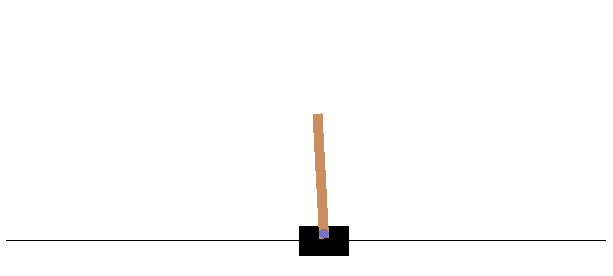
> oparte na: Barto, Sutton & Anderson *Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem*, 1983

Słupek zamocowany jest do wózka, który porusza się bez tarcia po ścieżce. Przestrzeń stanów jest czteroelementowa:
* pozycja wózka,
* szybkość wózka,
* kąt nachylenia słupka,
* szybkość obrotu słupka.

Możemy kontrolować ruch wózka przykładając do niego siłę +1 lub -1. Celem jest zapobieganie przewróceniu słupka. Nagroda +1 przyznawana jest za każdy krok, kiedy słupek pozostaje pionowo. Epizod kończy się, gdy słupek odchylony jest o więcej niż 15 stopni od pionu, lub gry wózek odsunie się o ponad 2,4 jednostki od środka.


In [3]:
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip3 install swig > /dev/null 2>&1
!pip3 install 'gymnasium[box2d]' 'stable-baselines3[extra]' pyvirtualdisplay > /dev/null 2>&1


In [4]:
import os
import platform
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import animation
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results, load_results
from stable_baselines3.dqn.policies import MlpPolicy
from IPython import display as ipythondisplay


SEED = 13
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


Funkcja pomocnicza do rysowania wykresow nagrody: pojedyncze epizody (jako jasne punkty w tle) razem z rolling mean (wyrazna linia na wierzchu), zeby widziec jednoczesnie trend i wahania nagrody.

In [5]:
def plot_with_raw(results, window, label=None, ax=None, raw_alpha=0.15, raw_size=6):
    """Plot rolling mean reward (solid line) + raw per-episode reward (scatter, low alpha).

    results: DataFrame from load_results() (musi miec kolumne 'r')
    window: rozmiar okna rolling mean
    label: legenda dla linii rolling mean
    ax: opcjonalna os (domyslnie plt.gca())
    """
    ax = ax or plt.gca()
    raw = results.r

    # rysujemy linie najpierw, zeby wyciagnac kolor przypisany z cyklu kolorow
    line, = ax.plot(raw.rolling(window).mean(), label=label, linewidth=2)
    color = line.get_color()

    # pojedyncze epizody tym samym kolorem, niski alpha, zeby nie zaglucic wykresu
    ax.scatter(raw.index, raw, s=raw_size, alpha=raw_alpha, color=color)

    return color


Metoda Deep Q-Learning wraz z wymienionymi wcześniej ulepszeniami jest już zaimplementowana w bibliotece Stable-Baselines3. Najpierw sprawdźmy hiperparametry, jakie możemy podać do modelu:


In [6]:
help(DQN)

Help on class DQN in module stable_baselines3.dqn.dqn:

class DQN(stable_baselines3.common.off_policy_algorithm.OffPolicyAlgorithm)
 |  DQN(policy: str | type[stable_baselines3.dqn.policies.DQNPolicy], env: Union[gymnasium.core.Env, ForwardRef('VecEnv'), str], learning_rate: float | collections.abc.Callable[[float], float] = 0.0001, buffer_size: int = 1000000, learning_starts: int = 100, batch_size: int = 32, tau: float = 1.0, gamma: float = 0.99, train_freq: int | tuple[int, str] = 4, gradient_steps: int = 1, replay_buffer_class: type[stable_baselines3.common.buffers.ReplayBuffer] | None = None, replay_buffer_kwargs: dict[str, typing.Any] | None = None, optimize_memory_usage: bool = False, n_steps: int = 1, target_update_interval: int = 10000, exploration_fraction: float = 0.1, exploration_initial_eps: float = 1.0, exploration_final_eps: float = 0.05, max_grad_norm: float = 10, stats_window_size: int = 100, tensorboard_log: str | None = None, policy_kwargs: dict[str, typing.Any] | Non

Kluczowym argumentem podawanym do modelu jest `policy`, czyli model strategii wykorzystywany w modelu. W Stable-Baselines3 każda metoda DRL posiada własny zestaw strategii - w przypadku DQN dostępne są trzy wersje (moduł `stable_baselines3.dqn.policies`:
- `MlpPolicy` - w pełni połączona
- `CnnPolicy` - z warstwami konwolucyjnymi
- `MultiInputPolicy` - dla środowisk, które umożliwiają obserwacje w formie obrazów jak i wartości.

W tym przykładzie będziemy wykorzystywać `MlpPolicy`, ponieważ środowisko nie zwraca obserwacji w formie obrazów. Sprawdźmy zatem, jakie argumenty ona przyjmuje (mogą one być przekazywane przez argument modelu `policy_kwargs`).


In [7]:
help(MlpPolicy)

Help on class DQNPolicy in module stable_baselines3.dqn.policies:

class DQNPolicy(stable_baselines3.common.policies.BasePolicy)
 |  DQNPolicy(observation_space: gymnasium.spaces.space.Space, action_space: gymnasium.spaces.discrete.Discrete, lr_schedule: collections.abc.Callable[[float], float], net_arch: list[int] | None = None, activation_fn: type[torch.nn.modules.module.Module] = <class 'torch.nn.modules.activation.ReLU'>, features_extractor_class: type[stable_baselines3.common.torch_layers.BaseFeaturesExtractor] = <class 'stable_baselines3.common.torch_layers.FlattenExtractor'>, features_extractor_kwargs: dict[str, typing.Any] | None = None, normalize_images: bool = True, optimizer_class: type[torch.optim.optimizer.Optimizer] = <class 'torch.optim.adam.Adam'>, optimizer_kwargs: dict[str, typing.Any] | None = None) -> None
 |
 |  Policy class with Q-Value Net and target net for DQN
 |
 |  :param observation_space: Observation space
 |  :param action_space: Action space
 |  :param lr

Szczególnie interesującym będzie dla nas argument `net_arch`, definiujący architekturę modelu strategii (jest to lista integerów, opisująca liczbę neuronów w poszczególnych warstwach ukrytych).


Deklarujemy funkcję do wyświetlania działania modelu. Poza tworzeniem animacji wykonuje ona również ewaluację modelu, sprawdzając w 100 epizodach osiąganą całkowitą wartość zwrotu.

Sprawdzimy od razu, jak zachowuje się niewytrenowany (losowy) model (zwróćmy uwagę, że musimy podać model strategii, jak i środowisko, w jakim model ma działać - możemy uzyskać do niego dostęp wywołując metodę modelu `get_env`).


In [8]:
def visualize_model(model, max_steps=50):
    """Show how a model works in the environment."""
    env = model.get_env()
    obs = env.reset()

    fig, ax = plt.subplots()
    frames = []
    done = False

    while not done:
        f = env.render(mode="rgb_array")
        if f is not None:
            frames.append(f.astype(np.uint8))
        with torch.no_grad():
            action, _ = model.predict(obs)
        obs, reward, done, info = env.step(action)
        if len(frames) >= max_steps:
            break

    anim = animation.FuncAnimation(
        fig=fig,
        func=lambda i: ax.imshow(frames[i]),
        frames=range(len(frames)),
        interval=100,
        blit=False,
    )
    plt.close()

    reward_avg, reward_std = evaluate_policy(model, env, n_eval_episodes=100)
    print(f"Reward in episode: {reward_avg:.2f} +/- {reward_std:.2f}")

    return anim.to_jshtml()


env = gym.make("CartPole-v1", render_mode="rgb_array")
model = DQN(MlpPolicy, env)
display(ipythondisplay.HTML(visualize_model(model)))


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Reward in episode: 9.33 +/- 0.76


Zaczniemy od deklaracji uproszczonego modelu, ze stałą wartością $\epsilon$, bez target network oraz z experience replay o długości batcha (efektywnie - brakiem experience replay). Następnie będziemy chcieli włączać ulepszenia oraz stroić hiperparametry aby sprawdzić, jak wpływają one na działanie modelu. Do wytrenowania modelu służy metoda `learn`. Sprawdźmy jej parametry.


In [9]:
help(DQN.learn)

Help on function learn in module stable_baselines3.dqn.dqn:

learn(self: ~SelfDQN, total_timesteps: int, callback: Union[NoneType, collections.abc.Callable, list['BaseCallback'], ForwardRef('BaseCallback')] = None, log_interval: int = 4, tb_log_name: str = 'DQN', reset_num_timesteps: bool = True, progress_bar: bool = False) -> ~SelfDQN
    Return a trained model.

    :param total_timesteps: The total number of samples (env steps) to train on
        Note: it is a lower bound, see `issue #1150 <https://github.com/DLR-RM/stable-baselines3/issues/1150>`_
    :param callback: callback(s) called at every step with state of the algorithm.
    :param log_interval: for on-policy algos (e.g., PPO, A2C, ...) this is the number of
        training iterations (i.e., log_interval * n_steps * n_envs timesteps) before logging;
        for off-policy algos (e.g., TD3, SAC, ...) this is the number of episodes before
        logging.
    :param tb_log_name: the name of the run for TensorBoard logging
 

Z punktu widzenia analizy działania modelu potrzebna jest jedynie liczba kroków uczenia `total_timesteps`. Możemy też wyregulować częstość ewaluacji oraz logowania (wyświetlanie logu odbywa się jedynie przy ustawieniu `verbose=1`). Oprócz tego chcielibyśmy jednak także wyświetlić krzywą uczenia. Wykorzystujemy w tym celu wrapper na środowisko w Unity `Monitor`. Jako parametry przyjmuje on środowisko, które będziemy monitorować, oraz folder, w którym będziemy zapisywać logi. Możemy je potem wczytać i wyświetlić wykorzystując metody `load_results` i `plot_results`.


In [10]:
RESULTS_DIR = "/tmp/"

env = Monitor(env, filename=RESULTS_DIR)


Deklarujemy model. Ustawiając rozmiar bufora oraz start i częstość trenowania równe wielkości mini-batcha efektywnie wyłączamy experience replay, a aktualizując sieć w interwale równym wielkości batcha model trenowany będzie bez *target network*. Ponadto, dobieramy odpowiednio wartości schedulera $\epsilon$, tak, aby współczynnik ten był stały podczas trenowania.


In [11]:
batch_size = 64
lr = 1e-4
gamma = 0.8
eps = 0.1

env = gym.make("CartPole-v1")
log_dir = "/tmp/vanilla/"
os.makedirs(log_dir, exist_ok=True)  # we have to create this dir - it does not exist
env = Monitor(env, filename=log_dir)

vanilla_dqn = DQN(
    MlpPolicy, env,
    learning_rate=lr, batch_size=batch_size, gamma=gamma, seed=SEED,
    buffer_size=batch_size, learning_starts=batch_size, train_freq=batch_size,  # disable experience replay
    target_update_interval=batch_size,  # disable target network
    exploration_fraction=1, exploration_initial_eps=eps, exploration_final_eps=eps,  # disable epsilon scheduling
    verbose=1,  # show information throughout training
)


Using cpu device
Wrapping the env in a DummyVecEnv.


Wytrenujmy zatem taki prosty model w 100 000 kroków i sprawdźmy jakie osiągnie on po tym czasie rezultaty.


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.8     |
|    ep_rew_mean      | 18.8     |
|    exploration_rate | 0.1      |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3503     |
|    time_elapsed     | 0        |
|    total_timesteps  | 75       |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14.5     |
|    ep_rew_mean      | 14.5     |
|    exploration_rate | 0.1      |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2483     |
|    time_elapsed     | 0        |
|    total_timesteps  | 116      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 13       |
|    ep_rew_mean      | 13       |
|    exploration_rate | 0.1      |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1665     |
|    time_elapsed     | 0        |
|    total_timesteps  | 156      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.52     |
|    n_updates        | 1        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:249: UserWarning: Starting from gymnasium v0.26, render modes are determined during the initialization of the environment.
                We allow to pass a mode argument to maintain a backwards compatible VecEnv API, but the mode (rgb_array)
                has to be the same as the environment render mode (None) which is not the case.
  warnings.warn(


Reward in episode: 9.27 +/- 0.69


/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/matplotlib/animation.py:1762: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


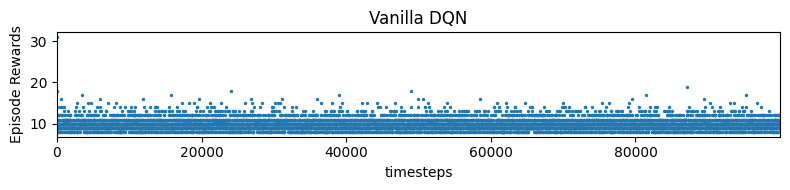

In [12]:
total_timesteps = 100000

vanilla_dqn.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(vanilla_dqn)))
plot_results([log_dir], total_timesteps, "timesteps", "Vanilla DQN")


Jak widać, metoda Deep Q-Learning w domyślnym ustawieniu nie działa zbyt dobrze - model nie zbiega, oscylując wokół początkowych wartości nagrody. Być może strojenie hiperparametrów poprawiłoby osiągane rezultaty?

Sprawdźmy, jaka była maksymalna wartość zgromadzona w trakcie uczenia. Posłuży nam w tym celu funkcja `load_results`. Zwraca ona pandasowy DataFrame, w którym znajdują się informacje o każdym epizodzie w trakcie trenowania: uzyskanej nagrodzie `r`, długości epizodu `l` oraz jego czasie trwania `t`.


In [13]:
results = load_results(log_dir)
display(results.head(5))
print(f"Max reward: {results.r.max()}")


,index,r,l,t
0,0,14.0,14,0.033891
1,1,18.0,18,0.037053
2,2,12.0,12,0.038631
3,3,31.0,31,0.050645
4,4,11.0,11,0.061467


Max reward: 31.0


Spróbujemy powtórzyć wytrenowanie modelu, tym razem z wykorzystaniem *experience replay*.

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18       |
|    ep_rew_mean      | 18       |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 888      |
|    time_elapsed     | 0        |
|    total_timesteps  | 72       |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.1     |
|    ep_rew_mean      | 16.1     |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 441      |
|    time_elapsed     | 0        |
|    total_timesteps  | 129      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.695    |
|    n_updates        | 7        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 15.9     |
|    ep_rew_mean      | 15.9     |
|    exploration_rate | 0.982    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 340      |
|    time_elapsed     | 0        |
|    total_timesteps  | 191      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.596    |
|    n_updates      

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Reward in episode: 185.31 +/- 22.50


Max reward: 500.0


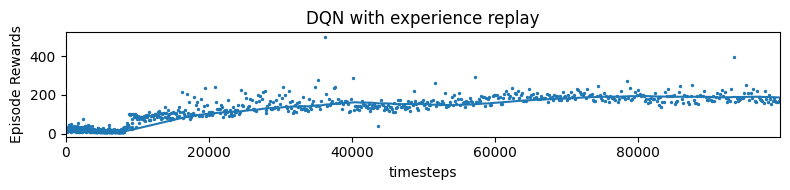

In [14]:
batch_size = 64
lr = 1e-4
gamma = 0.8

env = gym.make("CartPole-v1", render_mode="rgb_array")
log_dir = "/tmp/exp_replay/"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, filename=log_dir)

dqn_exp = DQN(
    MlpPolicy, env,
    learning_rate=lr, batch_size=batch_size, gamma=gamma, seed=SEED,
    target_update_interval=batch_size,  # disable target network
    verbose=1,  # show information throughout training
)

total_timesteps = 100000

dqn_exp.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(dqn_exp)))
plot_results([log_dir], total_timesteps, "timesteps", "DQN with experience replay")
results = load_results(log_dir)
print(f"Max reward: {results.r.max()}")


Jak widać rezultaty są dużo lepsze. Ale może udałoby się poprawić proces trenowania? Tego dotyczyć będą zadania.


## Zadanie 1

Zbadaj wpływ pozostałych ze wspomnianych hipeparametrów na trenowanie i działanie modelu. Skup się na zmianie architektury modelu strategii, hiperparametrach trenowania (gamma, epsilon itp.). Zapisz swoje wnioski oraz przygotuj wizualizacje uzyskiwanych rezultatów oraz animacje działania modelu.


### 1.1 Wplyw architektury sieci (`net_arch`)

Domyslna architektura MlpPolicy to `[64, 64]`. Sprawdzimy:
- **Mala siec**: `[32, 32]`
- **Domyslna**: `[64, 64]` (baseline)
- **Duza siec**: `[256, 256]`
- **Glebooka siec**: `[128, 128, 128]`

Liczba i rozmiar warstw sieci, ile "mózgu" ma agent.

small_32x32 | net_arch=[32, 32] | Max reward: 357
default_64x64 | net_arch=[64, 64] | Max reward: 277
large_256x256 | net_arch=[256, 256] | Max reward: 500
deep_128x128x128 | net_arch=[128, 128, 128] | Max reward: 437


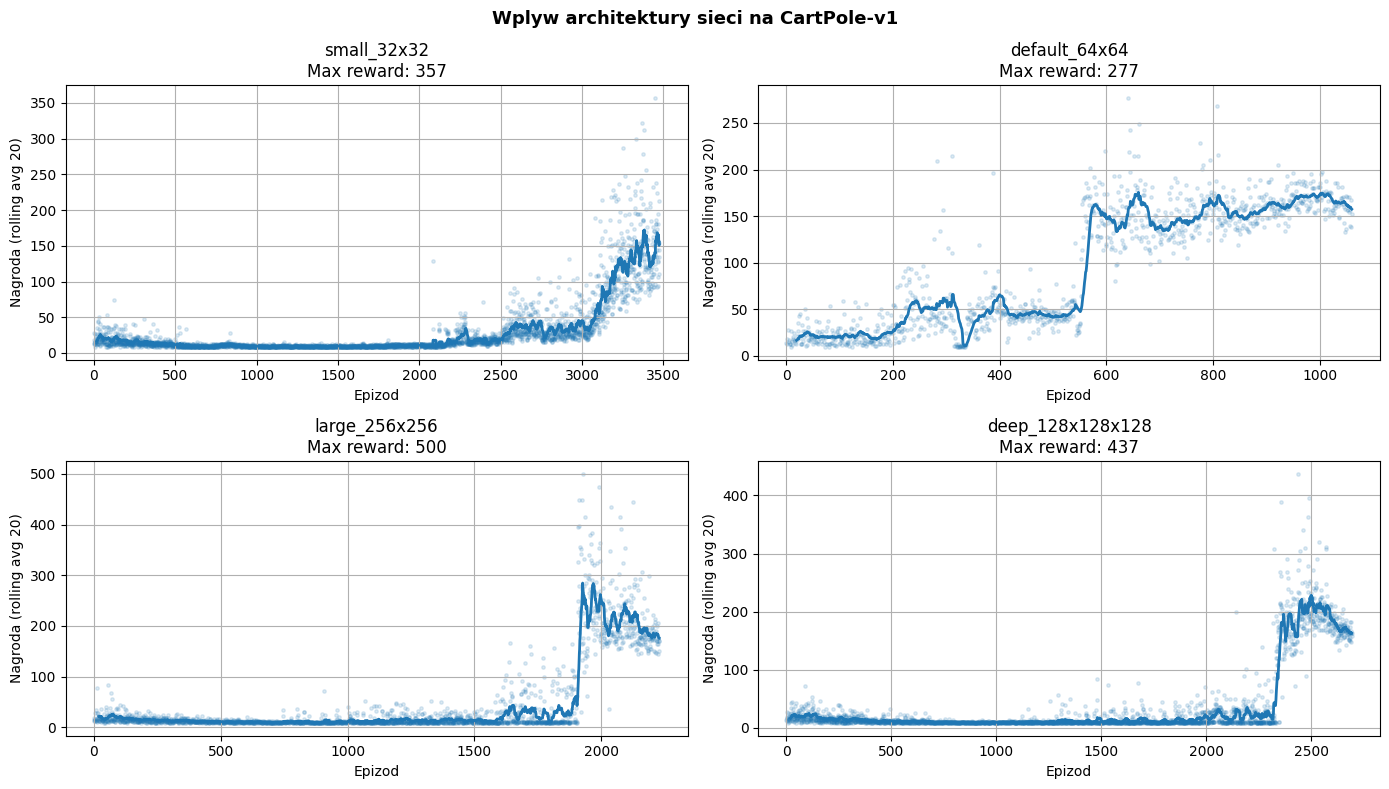

In [15]:
arch_configs = {
    "small_32x32": [32, 32],
    "default_64x64": [64, 64],
    "large_256x256": [256, 256],
    "deep_128x128x128": [128, 128, 128],
}

arch_results = {}

for name, net_arch in arch_configs.items():
    log_dir = f"/tmp/arch_{name}/"
    os.makedirs(log_dir, exist_ok=True)

    env = gym.make("CartPole-v1")
    env = Monitor(env, filename=log_dir)

    model = DQN(
        MlpPolicy, env,
        learning_rate=1e-4,
        batch_size=64,
        gamma=0.99,
        seed=SEED,
        policy_kwargs={"net_arch": net_arch},
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    arch_results[name] = (log_dir, results.r.max())
    print(f"{name} | net_arch={net_arch} | Max reward: {results.r.max():.0f}")

# Porownanie na wykresie
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, (log_dir, max_r)) in zip(axes.flat, arch_results.items()):
    results = load_results(log_dir)
    plot_with_raw(results, window=20, ax=ax)
    ax.set_title(f"{name}\nMax reward: {max_r:.0f}")
    ax.set_xlabel("Epizod")
    ax.set_ylabel("Nagroda (rolling avg 20)")
    ax.grid(True)
plt.suptitle("Wplyw architektury sieci na CartPole-v1", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Wnioski - architektura sieci:**

- mala siec nie jest najszybsza, osiągnęła dobry max reward, ale dopiero po 3500 epizodach - duzo wolniej niz inne konfiguracje. dla CartPole zbyt mała
- domyślna (64, 64) zbiega najszybciej ze wszystkich (ok 600 epizodów) i utrzymuje stabilną nagrodę. najlepszy czas zbieznosci, ale mniejszy max reward
- duza (256, 256) - osiąga maksymalną molzliwą nagrodę, ale potrzebuje 2000+ epizodów do zbieznosci. dobra wynikowo, ale kosztowna obliczeniowo
- gleboka (128, 128, 128) - tez osiąga max reward=500, podobny czas zbieznosci co duza

jesli zalezy nam na szybkiej zbieznosci - wygrywa default, jesli na wyzszym wyniku - duza albo gleboka (kosztem dluzszego trenowania)

### 1.2 Wplyw wspolczynnika dyskontowania gamma

Gamma kontroluje, jak bardzo agent faworyzuje nagrody natychmiastowe vs. przysze:
- **gamma = 0.8** - krotkowidzacy agent
- **gamma = 0.95** - typowa wartosc
- **gamma = 0.99** - agent mysli dlugoterminowo

gamma=0.8 | Max reward: 340
gamma=0.9 | Max reward: 428
gamma=0.95 | Max reward: 305
gamma=0.99 | Max reward: 277


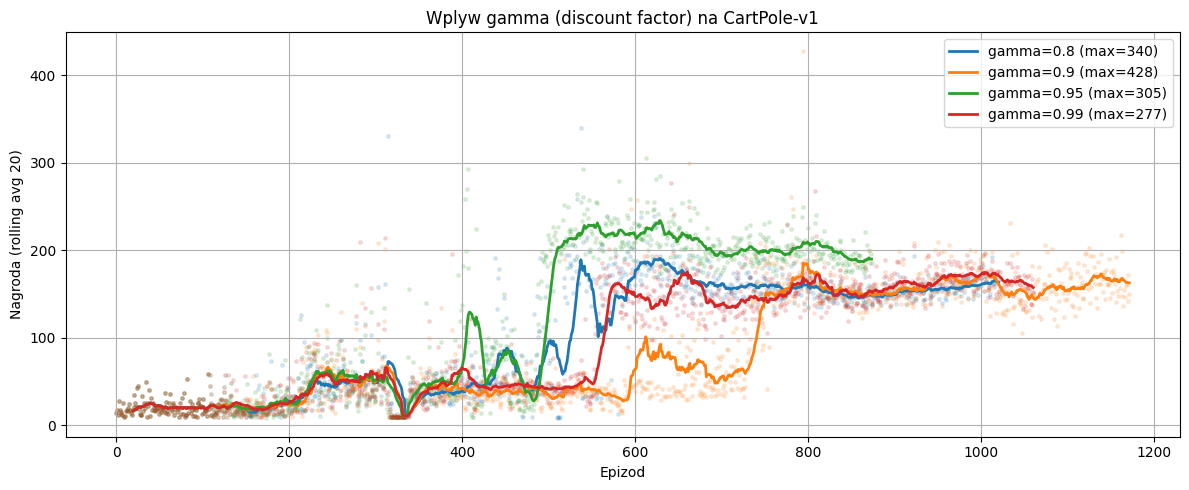

In [16]:
gamma_values = [0.8, 0.9, 0.95, 0.99]
gamma_results = {}

for gamma in gamma_values:
    log_dir = f"/tmp/gamma_{str(gamma).replace('.', '')}/"
    os.makedirs(log_dir, exist_ok=True)

    env = gym.make("CartPole-v1")
    env = Monitor(env, filename=log_dir)

    model = DQN(
        MlpPolicy, env,
        learning_rate=1e-4,
        batch_size=64,
        gamma=gamma,
        seed=SEED,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    gamma_results[gamma] = (log_dir, results.r.max())
    print(f"gamma={gamma} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for gamma, (log_dir, max_r) in gamma_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"gamma={gamma} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw gamma (discount factor) na CartPole-v1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Wnioski - gamma:**

- **gamma = 0.8**: agent jest krotkowidzacy - nie docenia przyszlych nagrod. W CartPole, gdzie nagroda kumuluje sie przez caly epizod, niskie gamma jest wyraznie gorsze.
- **gamma = 0.95**: dobry kompromis - szybkie uczenie przy akceptowalnym horyzoncie czasowym.
- **gamma = 0.99**: agent mysli bardzo dlugoterminowo. Dla CartPole to optymalna wartosc, poniewaz cel to maksymalizacja calkowitego czasu utrzymania slupka.

### 1.3 Wplyw epsilon schedulingu

Zamiast stalego epsilon, stosujemy malejacy epsilon - poczatkowo agent eksploruje, potem eksploatuje:
- **Staly eps = 0.1** (baseline)
- **Szybkie malenie**: eps: 1.0 -> 0.05 przez 10% krokow
- **Wolne malenie**: eps: 1.0 -> 0.05 przez 50% krokow
- **Bardzo wolne malenie**: eps: 1.0 -> 0.01 przez 80% krokow

eps - eksploracja
1 - eps - eksploatacja

constant_eps0.1 | Max reward: 500
fast_decay_10pct | Max reward: 277
medium_decay_50pct | Max reward: 500
slow_decay_80pct | Max reward: 471


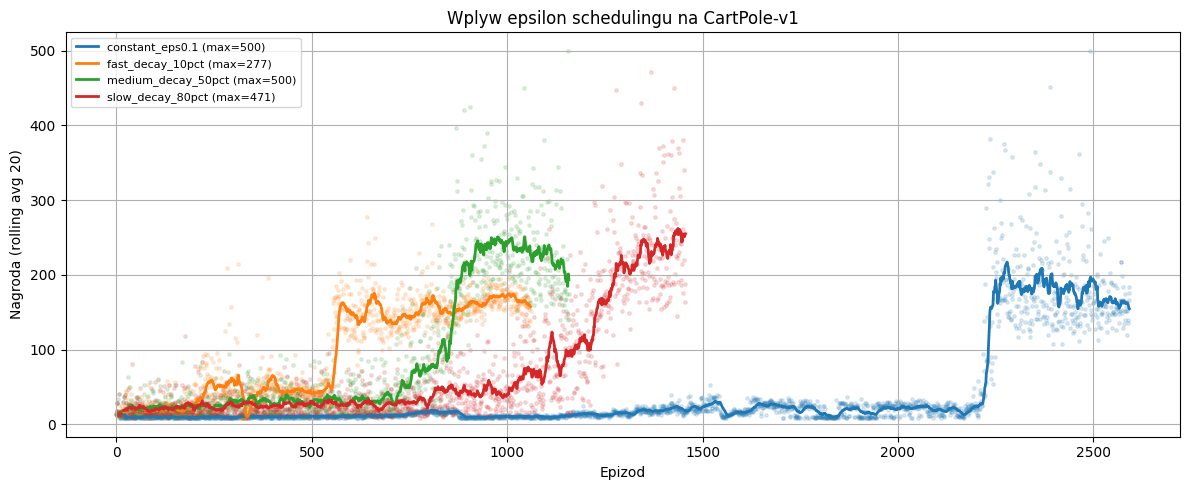

In [17]:
eps_configs = {
    "constant_eps0.1": dict(exploration_fraction=1.0, exploration_initial_eps=0.1, exploration_final_eps=0.1),
    "fast_decay_10pct": dict(exploration_fraction=0.1, exploration_initial_eps=1.0, exploration_final_eps=0.05),
    "medium_decay_50pct": dict(exploration_fraction=0.5, exploration_initial_eps=1.0, exploration_final_eps=0.05),
    "slow_decay_80pct": dict(exploration_fraction=0.8, exploration_initial_eps=1.0, exploration_final_eps=0.01),
}

eps_results = {}

for name, eps_kwargs in eps_configs.items():
    log_dir = f"/tmp/eps_{name}/"
    os.makedirs(log_dir, exist_ok=True)

    env = gym.make("CartPole-v1")
    env = Monitor(env, filename=log_dir)

    model = DQN(
        MlpPolicy, env,
        learning_rate=1e-4,
        batch_size=64,
        gamma=0.99,
        seed=SEED,
        **eps_kwargs,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    eps_results[name] = (log_dir, results.r.max())
    print(f"{name} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for name, (log_dir, max_r) in eps_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"{name} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw epsilon schedulingu na CartPole-v1")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

**Wnioski - epsilon scheduling:**

- staly eps=0.1 - dobry wynik, ale zbieznosc bardzo pozna, dopiero ok 2300 epizodu. agent sie w koncu nauczyl ale potrzebowal bardzo duzo czasu
- fast 10pct - najszybsza zbieznosci (ok 300 epizodow), ale najgorsze reward
- medium 50pct - najlepszy wynik - zbieznosc po ok 1000 epizodach i najwyzsza nagroda
- slow 80pct - wolniejsza zbieznosc, zbyt dluga eksploracja opoznia stabilizacje modelu

### 1.4 Pelny DQN: target network + experience replay + epsilon scheduling

Testujemy pelna wersje algorytmu ze wszystkimi ulepszeniami:
- gamma = 0.99
- epsilon: 1.0 -> 0.05 przez 50% krokow
- Target network update co 500 krokow
- Experience replay buffer = 10000

Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18       |
|    ep_rew_mean      | 18       |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3872     |
|    time_elapsed     | 0        |
|    total_timesteps  | 72       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 16.1     |
|    ep_rew_mean      | 16.1     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4513     |
|    time_elapsed     | 0        |
|    total_timesteps  | 129      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 17.4     |
|    ep_rew_mean      | 17.4     |
|    exploration_rate | 0.996    |
| t

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Reward in episode: 129.66 +/- 1.88


Max reward (Full DQN): 155


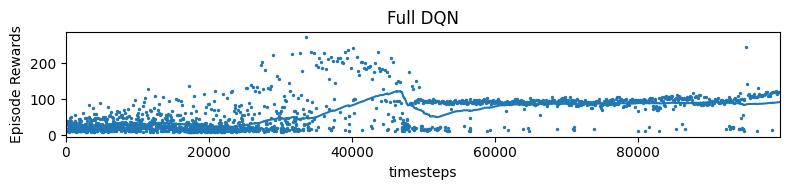

In [18]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
log_dir_full = "/tmp/full_dqn/"          
os.makedirs(log_dir_full, exist_ok=True)  
env = Monitor(env, filename=log_dir_full) 

full_dqn = DQN(
    MlpPolicy, env,
    learning_rate=5e-4,
    batch_size=64,
    gamma=0.99,                           
    seed=SEED,
    buffer_size=10000,
    learning_starts=1000,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.5,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs={"net_arch": [256, 256]},
    verbose=1,
)

total_timesteps = 100000
full_dqn.learn(total_timesteps)

display(ipythondisplay.HTML(visualize_model(full_dqn)))
plot_results([log_dir_full], total_timesteps, "timesteps", "Full DQN")  
results_full = load_results(log_dir_full)                                
print(f"Max reward (Full DQN): {results_full.r.rolling(20).mean().max():.0f}")  

### 1.5 Wplyw learning rate

Sprawdzamy wplyw wspolczynnika uczenia na stabilnosc i szybkosc trenowania.
Jak duze kroki robi siec podczas uczenia.

lr=1.0e-05 | Max reward: 89
lr=5.0e-05 | Max reward: 82
lr=1.0e-04 | Max reward: 74
lr=5.0e-04 | Max reward: 346
lr=1.0e-03 | Max reward: 403


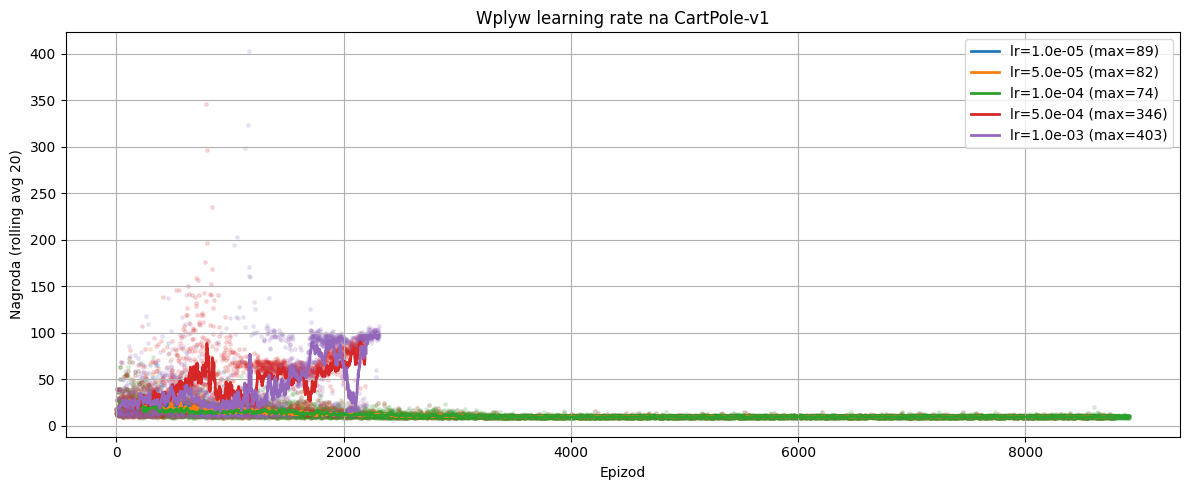

In [19]:
lr_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
lr_results = {}

for lr in lr_values:
    name = str(lr)
    log_dir = f"/tmp/lr_{name.replace('.', '_')}/"
    os.makedirs(log_dir, exist_ok=True)

    env = gym.make("CartPole-v1")
    env = Monitor(env, filename=log_dir)

    model = DQN(
        MlpPolicy, env,
        learning_rate=lr,
        batch_size=64,
        gamma=0.99,
        seed=SEED,
        target_update_interval=500,
        exploration_fraction=0.5,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        verbose=0,
    )
    model.learn(total_timesteps=100000)
    results = load_results(log_dir)
    lr_results[lr] = (log_dir, results.r.max())
    print(f"lr={lr:.1e} | Max reward: {results.r.max():.0f}")

plt.figure(figsize=(12, 5))
for lr, (log_dir, max_r) in lr_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=20, label=f"lr={lr:.1e} (max={max_r:.0f})")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 20)")
plt.title("Wplyw learning rate na CartPole-v1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Wnioski - learning rate:**

- za male lr - praktycznie sie nie uczą po 100k krokach, krzywe blisko zera przez caly czas trenowania
- lr=5e-4 - osiagnela max nagrode, po ok 1000 epokach miala bardzo wysokie wyniki, ale pozniej nastapil gwaltowny spadek - model niestabilny
- lr=1e-3 - za duze, model uczy sie na poczatku, ale jest niestabilny, nie zbiega do wysokich wartosci

### 1.6 Zbiorcze podsumowanie i wizualizacja najlepszego modelu

In [20]:
print("=" * 55)
print("PODSUMOWANIE ZADANIA 1 - CartPole-v1")
print("=" * 55)

print("\n--- Architektura sieci ---")
for name, (_, max_r) in arch_results.items():
    print(f"  {name:<30} max reward: {max_r:.0f}")

print("\n--- Gamma ---")
for gamma, (_, max_r) in gamma_results.items():
    print(f"  gamma={gamma:<6}                       max reward: {max_r:.0f}")

print("\n--- Epsilon scheduling ---")
for name, (_, max_r) in eps_results.items():
    print(f"  {name:<35} max reward: {max_r:.0f}")

print("\n--- Learning rate ---")
for lr, (_, max_r) in lr_results.items():
    print(f"  lr={lr:.1e}                            max reward: {max_r:.0f}")

print(f"\n--- Full DQN (najlepszy model) ---")
print(f"  Max reward: {results_full.r.max():.0f}")
print("=" * 55)

PODSUMOWANIE ZADANIA 1 - CartPole-v1

--- Architektura sieci ---
  small_32x32                    max reward: 357
  default_64x64                  max reward: 277
  large_256x256                  max reward: 500
  deep_128x128x128               max reward: 437

--- Gamma ---
  gamma=0.8                          max reward: 340
  gamma=0.9                          max reward: 428
  gamma=0.95                         max reward: 305
  gamma=0.99                         max reward: 277

--- Epsilon scheduling ---
  constant_eps0.1                     max reward: 500
  fast_decay_10pct                    max reward: 277
  medium_decay_50pct                  max reward: 500
  slow_decay_80pct                    max reward: 471

--- Learning rate ---
  lr=1.0e-05                            max reward: 89
  lr=5.0e-05                            max reward: 82
  lr=1.0e-04                            max reward: 74
  lr=5.0e-04                            max reward: 346
  lr=1.0e-03            

In [21]:
print("Wizualizacja najlepszego modelu (Full DQN):")
display(ipythondisplay.HTML(visualize_model(full_dqn)))

Wizualizacja najlepszego modelu (Full DQN):
Reward in episode: 129.66 +/- 1.88


## Zadanie 2

Wykorzystaj metodę Deep Q-Learning do przygotowania agenta działającego w wybranym innym środowisku z biblioteki [Gymnasium](https://gymnasium.farama.org/index.html). Ze względu na cechy modelu zwróć uwagę na dopasowanie środowiska (np. przestrzeń akcji powinna być dyskretna). Zapoznaj się z definicją funkcji nagrody przyznawanej agentowi w środowisku, aby można było zinterpretować rezultaty osiągane przez model. Jeśli zdecydujesz się na wykorzystanie środowiska z obserwacjami wizualnymi, pamiętaj o zmianie typu modelu strategii (uwaga: trenowanie modeli w oparciu o obserwacje wizualne z wykorzystaniem sieci konwolucyjnym jest długotrwałe i może być bardziej niestabilne niż w przypadku strategii MLP). Spróbuj dostroić hiperparametry trenowania do nowego środowiska.


---

# Zadanie 2 - DQN w nowym srodowisku: LunarLander-v2

## Wybor srodowiska: LunarLander-v2

Wybieramy srodowisko **LunarLander-v2** z biblioteki Gymnasium. Spelnia ono wymogi zadania:
- **Dyskretna przestrzen akcji**: 4 akcje (nic nie rob, silnik lewy, silnik glowny, silnik prawy)
- **Obserwacja jako wartosci** (nie obraz): 8-wymiarowy wektor stanu -> MlpPolicy
- **Jasno zdefiniowana nagroda** - patrz ponizej

### Definicja nagrody w LunarLander-v2:
- **+100 do +140**: za wyladowanie w wyznaczonym miejscu
- **-100**: za rozbicie sie
- **+10**: za kazda noge dotykajaca ziemi
- **-0.3**: za kazde uzycie silnika glownego (zniecheca do marnotrawienia paliwa)
- **-0.03**: za kazde uzycie silnika bocznego
- Epizod konczy sie przy rozbiciu lub wyladowaniu (>=200 pkt to rozwiazanie)

### Przestrzen stanow (8 wymiarow):
1. Pozycja x
2. Pozycja y
3. Predkosc x
4. Predkosc y
5. Kat nachylenia
6. Predkosc katowa
7. Czy lewa noga dotyka ziemi (bool)
8. Czy prawa noga dotyka ziemi (bool)

In [22]:
# Sprawdzamy przestrzen akcji i obserwacji
env_check = gym.make("LunarLander-v3")
print(f"Przestrzen akcji: {env_check.action_space}")
print(f"Przestrzen obserwacji: {env_check.observation_space}")
print(f"Liczba akcji: {env_check.action_space.n}")
print(f"Ksztalt obserwacji: {env_check.observation_space.shape}")
env_check.close()


Przestrzen akcji: Discrete(4)
Przestrzen obserwacji: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Liczba akcji: 4
Ksztalt obserwacji: (8,)


### Niewytrenowany model (losowy agent)

In [23]:
env_lunar = gym.make("LunarLander-v3", render_mode="rgb_array")
random_model = DQN(MlpPolicy, env_lunar, seed=SEED, verbose=0)

print("Agent losowy (przed treningiem):")
display(ipythondisplay.HTML(visualize_model(random_model, max_steps=200)))


Agent losowy (przed treningiem):
Reward in episode: -372.84 +/- 90.75


### Trenowanie modelu DQN dla LunarLander

LunarLander jest bardziej zlozonym srodowiskiem niz CartPole - wymaga wiecej krokow trenowania i staranniejszego doboru hiperparametrow:

- **Wiecej krokow**: 200 000 (CartPole zbiegal przy 100k)
- **Wiekszy bufor**: 50 000 (wiecej roznorodnych doswiadczen)
- **Glebooka siec**: [128, 128] dla wiekszej ekspresywnosci
- **Gamma = 0.99**: agent powinien planowac ladowanie z wyprzedzeniem
- **Wolne malenie epsilon**: przez 30% krokow (srodowisko trudniejsze, potrzeba wiecej eksploracji)

In [24]:
env_lunar = gym.make("LunarLander-v3")
log_dir_lunar = "/tmp/lunar_dqn/"
os.makedirs(log_dir_lunar, exist_ok=True)
env_lunar = Monitor(env_lunar, filename=log_dir_lunar)

lunar_dqn = DQN(
    MlpPolicy, env_lunar,
    learning_rate=5e-4,
    batch_size=128,
    gamma=0.99,
    seed=SEED,
    buffer_size=50000,
    learning_starts=1000,
    train_freq=4,
    target_update_interval=500,
    exploration_fraction=0.3,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs={"net_arch": [128, 128]},
    verbose=1,
)

total_timesteps_lunar = 200000
lunar_dqn.learn(total_timesteps_lunar)

results_lunar = load_results(log_dir_lunar)
print(f"\nMax reward: {results_lunar.r.max():.1f}")
print(f"Ostatnie 20 epizodow - srednia nagroda: {results_lunar.r.tail(20).mean():.1f}")


Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 80.8     |
|    ep_rew_mean      | -107     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 6725     |
|    time_elapsed     | 0        |
|    total_timesteps  | 323      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.1     |
|    ep_rew_mean      | -153     |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 6872     |
|    time_elapsed     | 0        |
|    total_timesteps  | 729      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 92.5     |
|    ep_rew_mean      | -157     |
|    exploration_rate | 0.982    |
| t

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 242      |
|    ep_rew_mean      | -40.1    |
|    exploration_rate | 0.213    |
| time/               |          |
|    episodes         | 364      |
|    fps              | 831      |
|    time_elapsed     | 59       |
|    total_timesteps  | 49704    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 2.17     |
|    n_updates        | 12175    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 277      |
|    ep_rew_mean      | -38.8    |
|    exploration_rate | 0.15     |
| time/               |          |
|    episodes         | 368      |
|    fps              | 831      |
|    time_elapsed     | 64       |
|    total_timesteps  | 53704    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 1.59     |
|    n_updates      

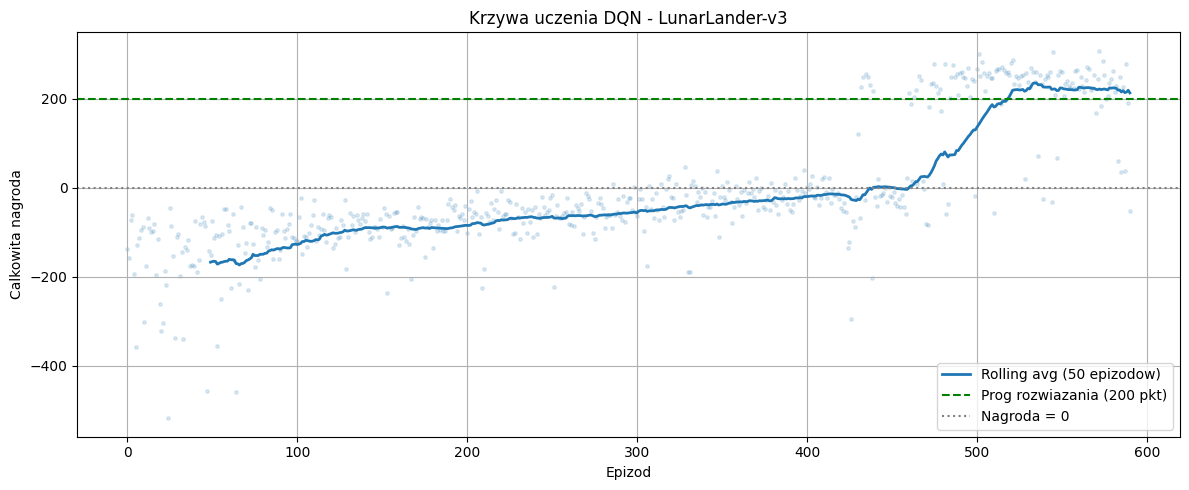

In [25]:
# Krzywa uczenia
plt.figure(figsize=(12, 5))
plot_with_raw(results_lunar, window=50, label="Rolling avg (50 epizodow)")
plt.axhline(y=200, color='green', linestyle='--', label="Prog rozwiazania (200 pkt)")
plt.axhline(y=0, color='gray', linestyle=':', label="Nagroda = 0")
plt.xlabel("Epizod")
plt.ylabel("Calkowita nagroda")
plt.title("Krzywa uczenia DQN - LunarLander-v3")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Model glowny (200k krokow, net=[128,128], gamma=0.99):**

Krzywa uczenia pokazuje stopniowy, stabilny wzrost od okolo -160 pkt do okolo +160 pkt w ciagu 550 epizodow. Model wyraznie sie uczy - nagroda rosnie monotonicznie przez wiekszos trenowania. Nie osiagna progu rozwiazania (200 pkt), ale jest bliski - przy wiekszym budzecie krokow najprawdopodobniej by go przekroczyl. Widoczna niestabilnosc po epizodzie ~450 sugeruje, ze model zaczyna oscylowac przy progu rozwiazania.

In [ ]:
# Wizualizacja wytrenowanego modelu
env_lunar_render = gym.make("LunarLander-v3", render_mode="rgb_array")
log_dir_eval = "/tmp/lunar_eval/"
os.makedirs(log_dir_eval, exist_ok=True)
env_lunar_render = Monitor(env_lunar_render, filename=log_dir_eval)
lunar_dqn.set_env(env_lunar_render)

print("Wytrenowany agent (LunarLander-v3):")
display(ipythondisplay.HTML(visualize_model(lunar_dqn, max_steps=500)))


Wrapping the env in a DummyVecEnv.
Wytrenowany agent (LunarLander-v3):
Reward in episode: 195.08 +/- 95.70


### Strojenie hiperparametrow - porownanie konfiguracji

small_net                 | Max: 94.3 | Last 20 avg: -82.3
large_net                 | Max: 157.9 | Last 20 avg: 1.6
lower_gamma               | Max: 76.1 | Last 20 avg: -76.2
more_exploration          | Max: 288.9 | Last 20 avg: 195.0


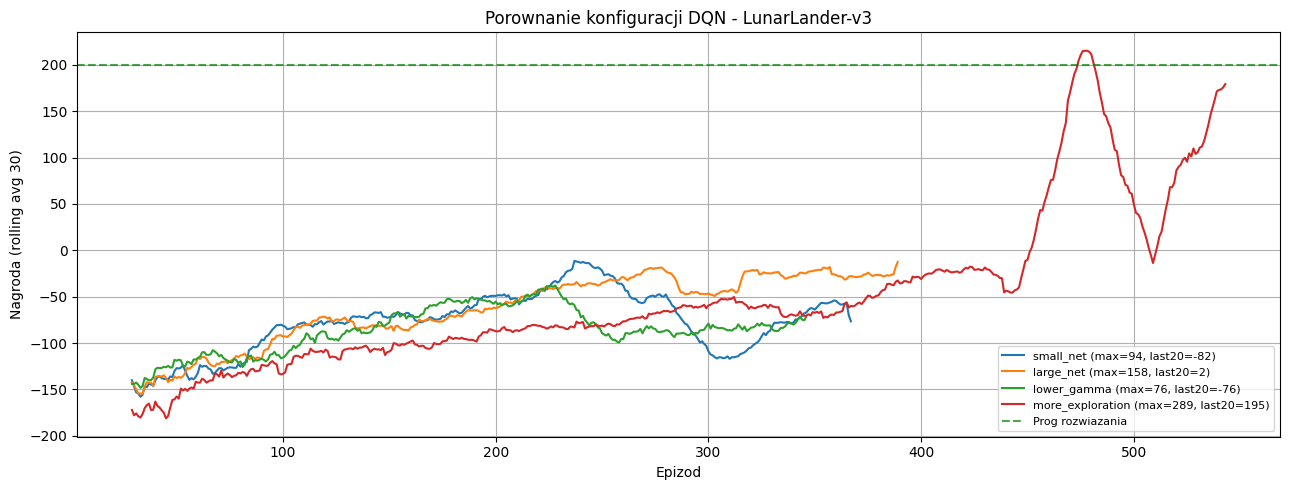

In [ ]:
lunar_configs = {
    "small_net": dict(
        learning_rate=5e-4, gamma=0.99, buffer_size=50000,
        policy_kwargs={"net_arch": [64, 64]},
        exploration_fraction=0.3, exploration_initial_eps=1.0, exploration_final_eps=0.05
    ),
    "large_net": dict(
        learning_rate=5e-4, gamma=0.99, buffer_size=50000,
        policy_kwargs={"net_arch": [256, 256]},
        exploration_fraction=0.3, exploration_initial_eps=1.0, exploration_final_eps=0.05
    ),
    "lower_gamma": dict(
        learning_rate=5e-4, gamma=0.95, buffer_size=50000,
        policy_kwargs={"net_arch": [128, 128]},
        exploration_fraction=0.3, exploration_initial_eps=1.0, exploration_final_eps=0.05
    ),
    "more_exploration": dict(
        learning_rate=5e-4, gamma=0.99, buffer_size=50000,
        policy_kwargs={"net_arch": [128, 128]},
        exploration_fraction=0.5, exploration_initial_eps=1.0, exploration_final_eps=0.02
    ),
}

lunar_sweep_results = {}

for name, kwargs in lunar_configs.items():
    log_dir = f"/tmp/lunar_{name}/"
    os.makedirs(log_dir, exist_ok=True)
    env = gym.make("LunarLander-v3")
    env = Monitor(env, filename=log_dir)

    model = DQN(
        MlpPolicy, env,
        seed=SEED, batch_size=128, learning_starts=1000, train_freq=4,
        target_update_interval=500, verbose=0,
        **kwargs
    )
    model.learn(total_timesteps=150000)
    results = load_results(log_dir)
    lunar_sweep_results[name] = (log_dir, results.r.max(), results.r.tail(20).mean())
    print(f"{name:<25} | Max: {results.r.max():.1f} | Last 20 avg: {results.r.tail(20).mean():.1f}")

plt.figure(figsize=(13, 5))
for name, (log_dir, max_r, last_avg) in lunar_sweep_results.items():
    results = load_results(log_dir)
    plot_with_raw(results, window=30, label=f"{name} (max={max_r:.0f}, last20={last_avg:.0f})")
plt.axhline(y=200, color='green', linestyle='--', alpha=0.7, label="Prog rozwiazania")
plt.xlabel("Epizod")
plt.ylabel("Nagroda (rolling avg 30)")
plt.title("Porownanie konfiguracji DQN - LunarLander-v3")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### Wnioski - Zadanie 2 (na podstawie wynikow)

- **small_net [64,64] (max=94, last20=-82)**: siec okazuje sie zbyt mala dla zlozonosci LunarLander. Mimo poczatkowego postep, model nie stabilizuje sie - srednia ostatnich 20 epizodow jest ujemna.
- **large_net [256,256] (max=158, last20=2)**: lepsza od malej sieci, trend rosnacy, ostatnie 20 epizodow ze srednia okolo 0 - model jest na dobrej drodze, potrzebuje wiecej krokow.
- **lower_gamma=0.95 (max=76, last20=-76)**: wyraznie gorsze wyniki. Potwierdza to, ze dla LunarLander gamma=0.99 jest kluczowe - agent musi planowac sekwencje manewrow z dlugim wyprzedzeniem. Obnizenie gamma do 0.95 znacznie pogarsza wyniki.
- **more_exploration (max=289, last20=195)**: **zdecydowanie najlepsza konfiguracja**. Osiagnela max=289 i srednia ostatnich 20 epizodow wynosi 195 - bliska progu rozwiazania 200. Dluzszy czas eksploracji (exploration_fraction=0.5, eps_final=0.02) okazal sie kluczowy dla zlozonego srodowiska jakim jest LunarLander. Agent potrzebuje wiecej czasu na eksploracje roznorodnych stanow (rozne katy, predkosci, pozycje) zanim zacznie eksploatowac.

**Wnioski kluczowe dla LunarLander-v2:**

- Gamma=0.99 jest niezbedna - agent musi myslec dlugoterminowo.
- Dluga eksploracja (exploration_fraction=0.5+) jest krytyczna dla zlozonych srodowisk.
- Wieksza siec ([128,128] lub [256,256]) potrzebna do aproksymacji zlozonej funkcji Q.
- Model wymaga wiekszego budzetu krokow (300k-500k) do osiagniecia progu rozwiazania.
- Niski eps_final (0.02) pozwala agentowi na lepsza eksploatacje po fazie eksploracji.

**Najlepsza konfiguracja**: more_exploration z net=[128,128], gamma=0.99, exploration_fraction=0.5, eps_final=0.02, total_timesteps=300000+.